In [ ]:
import numpy as np              # NumPy数值计算库，用于矩阵和数组操作
import matplotlib.pyplot as plt  # Matplotlib绑图库，用于图像和图表显示
import cv2 as cv                 # OpenCV计算机视觉库，用于图像处理

In [ ]:
def show(img):
    """自定义显示函数：自动判断灰度图或彩色图并正确显示"""
    if img.ndim == 2:  # 灰度图（二维数组），直接用gray色彩映射显示
        plt.imshow(img, cmap='gray')
    else:  # 彩色图（三维数组），OpenCV读取为BGR格式，需转为RGB才能用matplotlib正确显示
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.show()

## 1. 图像基础

### 1.1矩阵与分辨率

In [ ]:
# 创建2x4的随机整数矩阵模拟灰度图像，值范围[0, 256)，dtype=np.uint8表示无符号8位整数
# 灰度图是二维数组（高度 x 宽度）
A = np.random.randint(0, 256, (2,4), dtype=np.uint8)
A

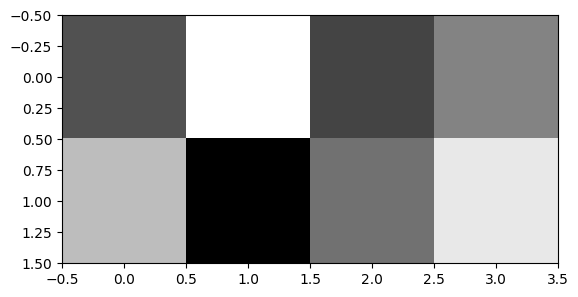

In [18]:
show(A)

In [ ]:
# 创建2x4x3的随机整数数组模拟彩色图像，shape为(高度, 宽度, 通道数)
# 彩色图是三维数组，第三个维度3表示BGR三个通道
B = np.random.randint(0, 256, (2,4,3), dtype=np.uint8)
show(B)

### 1.2 8位整形图像

In [ ]:
# 演示uint8类型的数据范围限制：只能表示0-255，超出范围会报OverflowError
# 注意：旧版NumPy会对超出范围的值做取模运算（如300%256=44），新版则直接报错
np.uint8([-1, 0, 10, 255, 300])

说明：np.uint8是一个数据类型，用于表示范围在0到255之间的无符号8位整数。对于不在0到255之间的数字，uint8会对其转换

### 1.3 浮点数图像

In [ ]:
# 将uint8矩阵转换为float32浮点类型，值范围仍为0-255
# float32图像在图像处理中更常用，因为可以表示负数和小数
A2 = np.float32(A)
show(A2)

In [ ]:
# 将像素值归一化到0-1区间，这是浮点图像的标准范围
# matplotlib默认将[0,1]视为灰度范围，将[0,255]也视为灰度范围但会自动放缩
A2 /= 255
A2

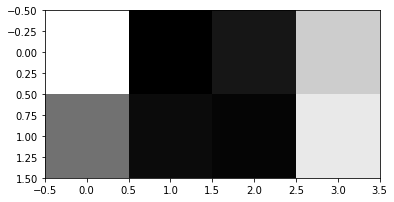

In [ ]:
show(A2)

为什么颜色会不一样？会自动放缩

## 2. 通道的分离和合并

In [ ]:
# cv.imread()读取彩色图片，返回BGR格式的NumPy数组，shape为(height, width, 3)
img = cv.imread('pic/cubic500x500.jpg')
show(img)

### 2.1通道的分离

In [ ]:
# cv.split()将BGR彩色图分离为三个独立的单通道灰度图
# b, g, r分别是蓝色、绿色、红色通道的二维灰度矩阵
b, g, r = cv.split(img)
show(r)  # 显示红色通道

In [ ]:
# img.shape返回(高度, 宽度, 通道数)，彩色图有3个维度
# r.shape返回(高度, 宽度)，单通道灰度图只有2个维度
print(img.shape)
print(r.shape)

(h, w, c)(高度，宽度，通道数)

In [ ]:
# 通过切片方式分离通道：img[:,:,2]取所有行、所有列的第3个通道（R通道）
# 效果与cv.split()中r = split结果相同
r = img[:,:,2]
show(r)

### 2.2通道的合并

In [ ]:
# cv.merge()合并三个单通道为BGR彩色图
# 注意：这里合并顺序是[r, g, b]，而OpenCV期望[b, g, r]，所以颜色会不对
img2 = cv.merge([r, g, b])
show(img2)

- 提问：为什么合并三个通道后，显示出来这张图跟原图不一样了？

## 3. 彩色图转换成灰度图

In [ ]:
# 手动实现彩色图转灰度图：对三个通道取等权重平均
# 这种方法将BGR三通道各占1/3权重，得到浮点型灰度图
gray1 = 1/3*b + 1/3*g + 1/3*r
show(gray1)

In [ ]:
gray1

array([[210.66666667, 210.66666667, 209.66666667, ..., 226.66666667,
        226.66666667, 226.66666667],
       [209.66666667, 209.66666667, 209.66666667, ..., 226.66666667,
        226.66666667, 225.66666667],
       [209.66666667, 209.66666667, 209.66666667, ..., 226.66666667,
        226.66666667, 226.66666667],
       ...,
       [212.66666667, 212.66666667, 212.66666667, ..., 230.        ,
        230.        , 230.        ],
       [212.66666667, 212.66666667, 212.66666667, ..., 230.        ,
        229.        , 229.        ],
       [213.66666667, 212.66666667, 212.66666667, ..., 230.        ,
        229.        , 229.        ]], shape=(500, 500))

In [ ]:
# 将浮点型灰度图转为uint8整型，使用np.uint8()强制类型转换
# 注意：浮点值会直接截断取整，不四舍五入
gray2 = np.uint8(gray1)
gray2

In [ ]:
# astype()方法也可以进行类型转换，效果与np.uint8()相同
# astype(as type)：将数组转换为指定的数据类型
gray3 = gray1.astype(np.uint8)
gray3

In [ ]:
# OpenCV官方彩色图转灰度图函数
# cvtColor：convert color的缩写；COLOR_BGR2GRAY使用加权平均法(0.299R+0.587G+0.114B)
# 比等权重平均法更符合人眼感知
gray4 = cv.cvtColor(img, cv.COLOR_BGR2GRAY) 
show(gray4)

## 4. 图像二值化

In [ ]:
# 手动实现图像二值化：用布尔索引将像素值分为两档
# 大于阈值125的设为255（白色），小于等于阈值的设为0（黑色）
thresh = 125
gray4[gray4 > thresh] = 255
gray4[gray4 <= thresh] = 0
show(gray4)

In [ ]:
# cv.threshold()函数实现二值化
# 参数：(输入灰度图, 阈值125, 最大值1, 二值化类型THRESH_BINARY)
# 大于125设为1（白色），小于等于125设为0（黑色），返回值为(阈值, 二值图)
show(gray2)
ignore, img_bin = cv.threshold(gray2, 125, 1, cv.THRESH_BINARY)
show(img_bin)

In [25]:
img_bin

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], shape=(500, 500), dtype=uint8)

## 5. 两图像的加减乘除

In [ ]:
# 以灰度模式读取四张图：前景(刺猬)、背景(条纹)、掩膜、噪声图
# 第二个参数0表示IMREAD_GRAYSCALE，直接以灰度模式读取
obj = cv.imread('pic/hedgehog500x500.jpg', 0)   # 前景图
bg  = cv.imread('pic/line500x500.jpg', 0)       # 背景图
mask  = cv.imread('pic/mask500x500.jpg', 0)     # 掩膜图（白色区域为目标区域）
noise = cv.imread('pic/hedgehog_noise_500x500.jpg', 0)  # 带噪声的前景图

# np.hstack()水平拼接四张图片并排显示
show(np.hstack([obj, bg, mask, noise]))

### 5.1相加

你可以使用OpenCV的cv.add()函数把两幅图像相加，或者可以简单地通过numpy操作添加两个图像，如res = img1 + img2。两个图像应该具有相同的大小和类型

- 1.两个图像直接相加

In [ ]:
# NumPy直接相加：逐元素加法，uint8类型下超过255会取模运算（溢出变暗/变白）
img_add = obj + bg
show(img_add)

为什么会这样？200+100相加，就会超过255，值就会溢出。我们来看一个例子。直接相加就是通过numpy相加，numpy相加是模运算。

In [ ]:
# 演示uint8取模运算：250+10=260，260%256=4，导致像素值反而变小（变暗）
x = np.uint8([250])
y = np.uint8([10])
print(x + y)  # 250+10 = 260 % 256 = 4，取模导致溢出

- 2.使用cv.add()函数相加

In [ ]:
# cv.add()：饱和运算相加，超过255的值截断为255（不会取模）
# 结果偏白是因为大量像素值被截断到255（白色）
img_add = cv.add(obj, bg)
show(img_add)
print(img_add)

图片偏白？这又是什么原因？cv.add()函数相加，超过255的值会被截断为255，因此就变成白色。

In [ ]:
# 演示cv.add()的饱和运算：250+10=260，截断为255（不会像取模那样变回小值）
x = np.uint8([250])
y = np.uint8([10])
print(cv.add(x, y))  # 250+10 = 260 => 截断为255

In [ ]:
# 给每张图乘以0.5权重后再相加，减少溢出
# 注意：obj*0.5后变为float64类型，cv.add也返回float64
img_add = cv.add(obj*0.5, bg*0.5)
show(img_add)

- 3.使用cv.addWeighted函数，即带权重的相加

In [ ]:
# cv.addWeighted()：带权重的图像融合函数
# 参数：(图1, 权重alpha, 图2, 权重beta, 附加常数gamma)
# 结果 = 图1*alpha + 图2*beta + gamma，结果为uint8类型
img_add2 = cv.addWeighted(obj, 0.5, bg, 0.5, 0)
show(img_add2)

cv.add(obj*0.5, bg*0.5)与cv.addWeighted(obj, 0.5, bg, 0.5, 0)这两种操作有什么区别？

In [ ]:
# 对比两种加法的返回类型：cv.add()返回float64，cv.addWeighted()返回uint8
img_add.dtype, img_add2.dtype

### 5.2减法

In [ ]:
# 从融合图中减去背景的一半，得到前景信息
img_sub = img_add - bg * 0.5
show(img_sub)
print(img_sub.max())

In [ ]:
# 因为img_add是0.5*前景+0.5*背景，减去0.5*背景后要乘以2才能恢复完整的前景
img_sub = np.uint8((img_add - bg * 0.5) * 2)
# cv.subtract()：OpenCV饱和减法，负值截断为0，不需要手动乘以2
# 这里没有乘以2，所以结果偏暗
img_sub2 = cv.subtract(img_add, bg * 0.5)

show(np.hstack([img_sub, img_sub2]))

### 5.3乘法

In [ ]:
# 将掩膜从[0,255]归一化到[0,1]区间，用于掩膜操作（白色区域=1，黑色区域=0）
mask = mask / 255

In [ ]:
# 图像乘法用于掩膜操作：前景图乘以掩膜，白色区域保留前景，黑色区域变为0
img_mul = obj * mask
# cv.multiply()：OpenCV乘法函数，obj*1.0将整型转为浮点型避免类型不匹配报错
img_mul2 = cv.multiply(obj * 1.0, mask)

show(np.hstack([img_mul, img_mul2]))

### 5.4除法

In [ ]:
# 图像除法：NumPy除法中除以0得到inf（无穷大），显示为白色
# cv.divide()同样存在除以0的问题
img_div = obj / noise
img_div2 = cv.divide(obj, noise)
show(np.hstack([img_div, img_div2]))

为什么左右两张图不一样？因为noise中有很多0，一个数除以0就等于无穷大，所以看上去更白

In [ ]:
# 加1避免除以0：noise+1使分母最小为1，消除inf问题
img_div = obj / (np.float64(noise) + 1)   # 转float64避免整数除法截断
img_div2 = cv.divide(obj, noise + 1)       # noise+1自动转为float
show(np.hstack([img_div, img_div2]))

## 6. 图像的线性和非线性变换

In [ ]:
# 读取灰度图用于线性和非线性变换的演示
img = cv.imread('pic/cat500x480.jpg', 0)
show(img)

### 6.1线性变化

- 手写线性变化

In [ ]:
# 手动实现线性变换：s = b + k*r（截距+斜率*像素值）
# 但img是uint8类型，乘以k=2后超过255会取模溢出，导致图像变暗/出现伪影
b = 20
k = 2
img2 = b + k * img
show(img2)
print(img2)

因为img是uint8类型的，乘以k之后会超过255，他会循环为一些奇怪的数字

In [ ]:
# 正确的线性变换：先转为int32避免溢出，再用np.clip截断到[0,255]
b = 20
k = 2
img2 = b + k * img.astype(np.int32)  # 转为int32，避免uint8溢出
img2 = np.clip(img2, 0, 255)          # 截断：小于0的设为0，大于255的设为255
show(img2)

In [ ]:
img2.max()

255

- convertScaleAbs函数

In [ ]:
# cv.convertScaleAbs()：OpenCV内置线性变换函数
# 参数：(输入图, alpha=斜率k, beta=截距b, 输出取绝对值)
# 结果 = |alpha * img + beta|，自动处理溢出，返回uint8
img3 = cv.convertScaleAbs(img, alpha=2, beta=20)
show(img3)

### 6.2非线性变换

In [ ]:
# 对数变换：s = a + ln(r+1)/b
# 对数变换可以扩展暗部细节、压缩亮部，+1避免log(0)的问题
# 注意：直接对uint8做log会溢出，需要先转为float
img4 = 10 + np.log(img + 1) / 0.1
show(img4)

In [44]:
np.uint8([-1, 254, 255])

OverflowError: Python integer -1 out of bounds for uint8

In [45]:
np.uint8([-1, 254, 255]) + 1

OverflowError: Python integer -1 out of bounds for uint8

In [ ]:
# 正确的对数变换：先将img转为float32，再进行对数运算，避免uint8溢出
img4 = 10 + np.log(img.astype(np.float32) + 1) / 0.1
show(img4)

### 6.3伽马变换

In [ ]:
# 伽马变换（幂律变换）：s = c * r^gamma
# 先归一化到[0,1]，做幂运算，再乘以255恢复到[0,255]
# gamma<1：提亮暗部（如0.5）；gamma>1：压暗亮部（如1.5）
img01 = img / 255                              # 归一化到[0,1]
img05 = np.power(img01, 0.5) * 255            # gamma=0.5，提亮暗部
img15 = np.power(img01, 1.5) * 255            # gamma=1.5，压暗亮部

# 并排显示：gamma<1 | 原图 | gamma>1
show(np.hstack([img05, img, img15]))